In [ ]:
%pip install ISLP pandas numpy matplotlib statsmodels -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from ISLP import load_data

pd.set_option("display.precision", 3)

## Question 2(a)

The response variable is CEO salary.

CEO salary is numerical, therefore this is a **regression** problem.

The purpose is to understand which factors affect CEO salary, therefore the
main objective is **inference**.

There are 500 companies:

\[
n = 500
\]

The predictors are:

1. profit
2. number of employees
3. industry

Therefore:

\[
p = 3
\]

### Final Answer

**Regression; Inference; n = 500; p = 3**

## Question 2(b)

The response is whether a new product will be a success or failure.

Because the response has two categories, this is a **classification** problem.

The objective is to predict whether a new product will succeed or fail,
therefore the goal is **prediction**.

There are 20 previously launched products:

\[
n = 20
\]

There are three explicitly stated predictors plus ten additional predictors:

\[
p = 3 + 10 = 13
\]

### Final Answer

**Classification; Prediction; n = 20; p = 13**

## Question 2(c)

The response is the percentage change in the USD/Euro exchange rate.

This is numerical, therefore the problem is **regression**.

The objective is explicitly to predict the exchange-rate change, so the
main goal is **prediction**.

There are approximately 52 weeks in one year:

\[
n = 52
\]

The predictors are percentage changes in:

1. US market,
2. British market,
3. German market.

Therefore:

\[
p = 3
\]

### Final Answer

**Regression; Prediction; n = 52; p = 3**

# Chapter 2 — Question 9: Auto Dataset

The Auto dataset is used to investigate vehicle characteristics and fuel economy.

In [4]:
from ISLP import load_data

Auto = load_data("Auto")
Auto.head()

Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [5]:
Auto.shape

(392, 8)

In [6]:
Auto.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin'],
      dtype='object')

In [7]:
Auto.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower        int64
weight            int64
acceleration    float64
year              int64
origin            int64
dtype: object

In [8]:
quantitative_vars = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "year"
]

qualitative_vars = ["origin", "name"]

print("Quantitative variables:", quantitative_vars)
print("Qualitative variables:", qualitative_vars)

Quantitative variables: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year']
Qualitative variables: ['origin', 'name']


In [9]:
ranges = Auto[quantitative_vars].agg(["min", "max"]).T

ranges

,min,max
mpg,9.0,46.6
cylinders,3.0,8.0
displacement,68.0,455.0
horsepower,46.0,230.0
weight,1613.0,5140.0
acceleration,8.0,24.8
year,70.0,82.0


In [11]:
#Question 9(c): Mean and standard deviation
means = Auto[quantitative_vars].mean()
stds = Auto[quantitative_vars].std()

full_stats = means.to_frame(name="Mean")
full_stats["Standard Deviation"] = stds

full_stats.round(3)

,Mean,Standard Deviation
mpg,23.446,7.805
cylinders,5.472,1.706
displacement,194.412,104.644
horsepower,104.469,38.491
weight,2977.584,849.403
acceleration,15.541,2.759
year,75.980,3.684


In [12]:
#Question 9(d): Remove observations
Auto_subset = Auto.drop(Auto.index[9:85])

Auto_subset.shape

(281, 8)

In [13]:
subset_stats = Auto_subset[quantitative_vars].agg(
    ["min", "max", "mean", "std"]
).T

subset_stats.round(3)

,min,max,mean,std
mpg,11.0,46.6,25.042,7.913
cylinders,3.0,8.0,5.274,1.632
displacement,68.0,455.0,179.374,95.513
horsepower,46.0,230.0,98.715,33.823
weight,1755.0,4952.0,2881.505,792.548
acceleration,9.5,24.6,15.739,2.570
year,70.0,82.0,77.509,2.989


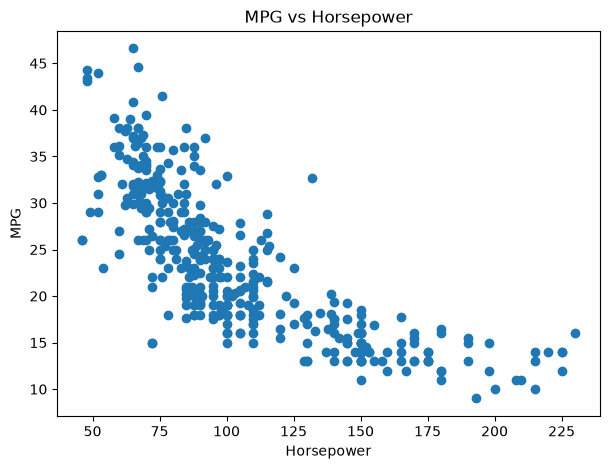

In [15]:
from matplotlib.pyplot import subplots
from matplotlib import pyplot as plt
plt.figure(figsize=(7, 5))
plt.scatter(Auto["horsepower"], Auto["mpg"])

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("MPG vs Horsepower")

plt.show()

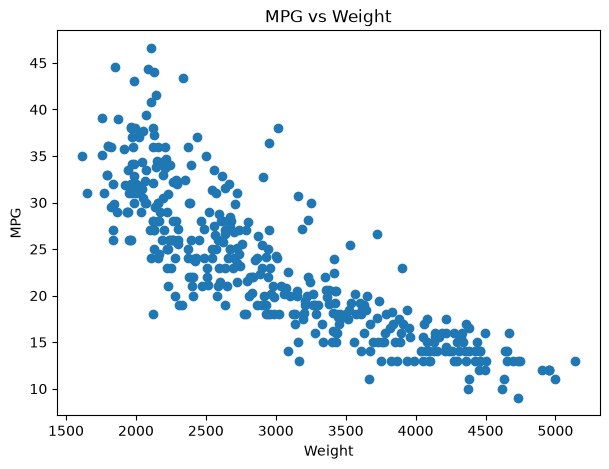

In [16]:
plt.figure(figsize=(7, 5))
plt.scatter(Auto["weight"], Auto["mpg"])

plt.xlabel("Weight")
plt.ylabel("MPG")
plt.title("MPG vs Weight")

plt.show()

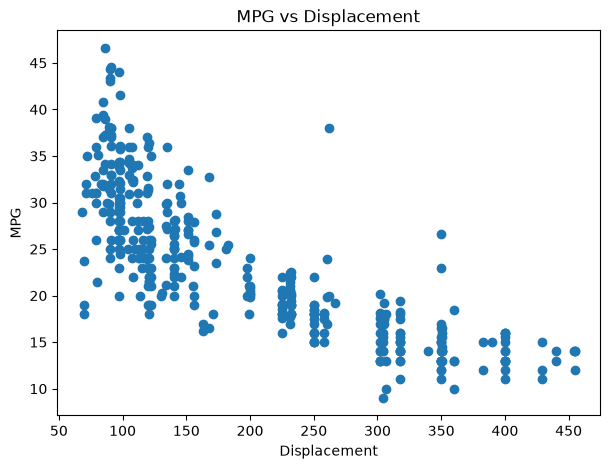

In [17]:
plt.figure(figsize=(7, 5))
plt.scatter(Auto["displacement"], Auto["mpg"])

plt.xlabel("Displacement")
plt.ylabel("MPG")
plt.title("MPG vs Displacement")

plt.show()

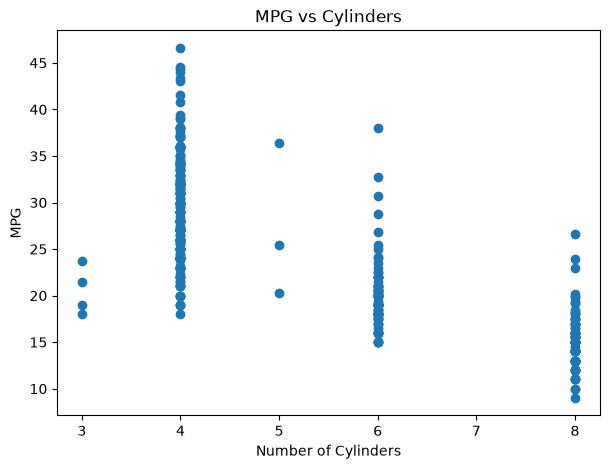

In [18]:
plt.figure(figsize=(7, 5))
plt.scatter(Auto["cylinders"], Auto["mpg"])

plt.xlabel("Number of Cylinders")
plt.ylabel("MPG")
plt.title("MPG vs Cylinders")

plt.show()

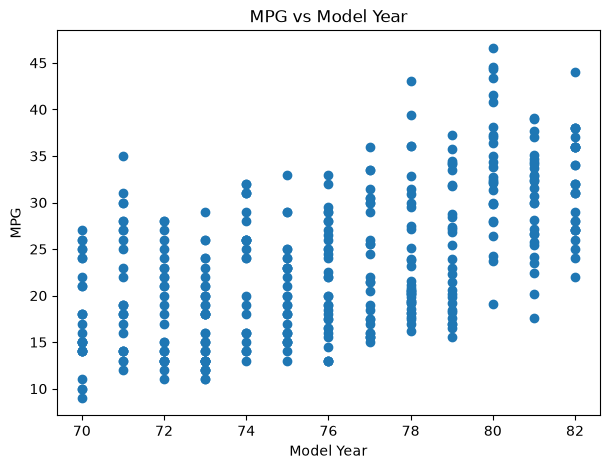

In [19]:
plt.figure(figsize=(7, 5))
plt.scatter(Auto["year"], Auto["mpg"])

plt.xlabel("Model Year")
plt.ylabel("MPG")
plt.title("MPG vs Model Year")

plt.show()

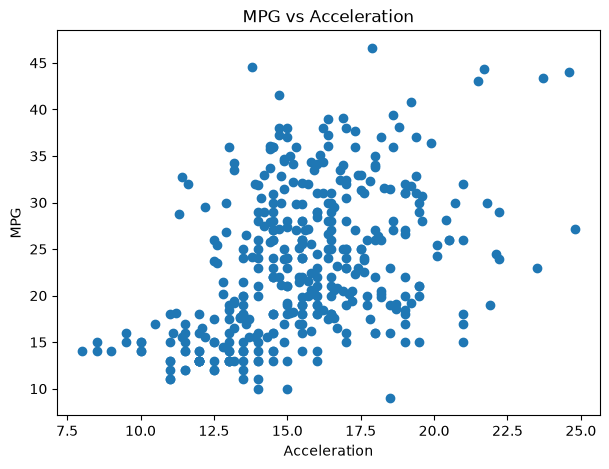

In [20]:
plt.figure(figsize=(7, 5))
plt.scatter(Auto["acceleration"], Auto["mpg"])

plt.xlabel("Acceleration")
plt.ylabel("MPG")
plt.title("MPG vs Acceleration")

plt.show()

In [21]:
mpg_correlations = (
    Auto[quantitative_vars]
    .corr()["mpg"]
    .sort_values()
)

mpg_correlations

weight         -0.832244
displacement   -0.805127
horsepower     -0.778427
cylinders      -0.777618
acceleration    0.423329
year            0.580541
mpg             1.000000
Name: mpg, dtype: float64

## Question 9(f) — Useful Predictors of MPG

The graphical analysis suggests that the strongest candidate predictors of MPG are:

- weight,
- horsepower,
- displacement,
- cylinders,
- year.

Weight, horsepower, displacement and cylinders show strong negative
relationships with MPG.

Year has a positive relationship with MPG, indicating that newer cars tend to
have better fuel economy.

Acceleration shows a weaker relationship.

The relationship between horsepower and MPG also shows some evidence of
non-linearity.

# Chapter 3 — Question 2

Both KNN classification and KNN regression identify the K observations
closest to a new observation.

## KNN Classification

Used when the response is categorical.

The class represented most strongly among the K nearest neighbours is selected.

Example:

If K = 5:

Yes, Yes, No, Yes, No

then Yes occurs 3 times and No occurs 2 times.

Therefore the prediction is Yes.

## KNN Regression

Used when the response is numerical.

Instead of voting, the responses of the K nearest neighbours are averaged.

For example:

20, 24, 22, 25, 19

\[
\frac{20+24+22+25+19}{5}=22
\]

Therefore the predicted value is 22.

## Final Answer

KNN classification predicts a categorical class using the majority/plurality
of the nearest neighbours, while KNN regression predicts a numerical value
using the average response of the nearest neighbours.

# Chapter 3 — Question 7

We want to prove:

\[
R^2 = Cor(X,Y)^2
\]

for simple linear regression, assuming:

\[
\bar{x}=\bar{y}=0
\]

Because the variables are centred:

\[
\hat{\beta}_0=0
\]

and the slope is:

\[
\hat{\beta}_1=
\frac{\sum x_i y_i}
{\sum x_i^2}
\]

Therefore:

\[
\hat{y}_i=\hat{\beta}_1x_i
\]

The coefficient of determination is:

\[
R^2=1-\frac{RSS}{TSS}
\]

Since the data are centred:

\[
TSS=\sum y_i^2
\]

and:

\[
TSS-RSS=\sum \hat{y}_i^2
\]

Therefore:

\[
R^2=
\frac{\sum \hat{y}_i^2}
{\sum y_i^2}
\]

Since:

\[
\hat{y}_i=\hat{\beta}_1x_i
\]

then:

\[
\sum\hat{y}_i^2=
\hat{\beta}_1^2\sum x_i^2
\]

Therefore:

\[
R^2=
\frac{\hat{\beta}_1^2\sum x_i^2}
{\sum y_i^2}
\]

Substituting:

\[
\hat{\beta}_1=
\frac{\sum x_i y_i}{\sum x_i^2}
\]

gives:

\[
R^2=
\frac{(\sum x_i y_i)^2}
{(\sum x_i^2)(\sum y_i^2)}
\]

Because the data are centred:

\[
Cor(X,Y)=
\frac{\sum x_i y_i}
{\sqrt{\sum x_i^2}\sqrt{\sum y_i^2}}
\]

Squaring gives:

\[
Cor(X,Y)^2=
\frac{(\sum x_i y_i)^2}
{(\sum x_i^2)(\sum y_i^2)}
\]

This is identical to the expression obtained for \(R^2\).

Therefore:

\[
\boxed{R^2=Cor(X,Y)^2}
\]

In [1]:
import numpy as np

rng = np.random.default_rng(10)

x = rng.normal(size=100)
y = 3 + 2*x + rng.normal(size=100)

import statsmodels.api as sm

X = sm.add_constant(x)

model = sm.OLS(y, X).fit()

r = np.corrcoef(x, y)[0, 1]

print("R-squared from regression:", model.rsquared)
print("Squared correlation:", r**2)
print("Difference:", model.rsquared - r**2)

R-squared from regression: 0.7121397645277343
Squared correlation: 0.7121397645277338
Difference: 5.551115123125783e-16


# Chapter 3 — Question 12

This question considers simple linear regression **without an intercept**.

For the regression of \(Y\) on \(X\):

\[
\hat{\beta}_{Y|X}
=
\frac{\sum x_i y_i}
{\sum x_i^2}
\]

If we reverse the variables and regress \(X\) on \(Y\):

\[
\hat{\beta}_{X|Y}
=
\frac{\sum x_i y_i}
{\sum y_i^2}
\]

The numerator is the same in both expressions. The difference comes from the denominator.

## Question 12(a) — When are the two coefficient estimates equal?

We want:

\[
\hat{\beta}_{Y|X}
=
\hat{\beta}_{X|Y}
\]

Substituting the formulas:

\[
\frac{\sum x_i y_i}{\sum x_i^2}
=
\frac{\sum x_i y_i}{\sum y_i^2}
\]

If the common numerator is non-zero, the coefficients are equal when:

\[
\sum x_i^2
=
\sum y_i^2
\]

There is also a special case.

If:

\[
\sum x_i y_i = 0
\]

then both slopes are zero and are therefore equal.

### Final Answer

For the non-zero slope case:

\[
\boxed{
\sum x_i^2
=
\sum y_i^2
}
\]

The two coefficient estimates are also equal when the common numerator is zero,
because both slopes then equal zero.

## Question 12(b) — Generate observations where the slopes are different

We generate \(n=100\) observations using:

\[
Y \approx 2X + \varepsilon
\]

There is no reason for:

\[
\sum x_i^2
\]

and

\[
\sum y_i^2
\]

to be equal.

Therefore, the two no-intercept regression coefficients should generally be different.

A random seed is used so that the results are reproducible.

In [2]:
rng = np.random.default_rng(1)

n = 100

x = rng.normal(size=n)
y = 2*x + rng.normal(size=n)

beta_y_on_x = np.sum(x*y) / np.sum(x**2)
beta_x_on_y = np.sum(x*y) / np.sum(y**2)

print("Slope for Y on X:", beta_y_on_x)
print("Slope for X on Y:", beta_x_on_y)

print()
print("Sum of X squared:", np.sum(x**2))
print("Sum of Y squared:", np.sum(y**2))

Slope for Y on X: 1.9762423774420508
Slope for X on Y: 0.3757436810334886

Sum of X squared: 73.05676144933012
Sum of Y squared: 384.24563132433116


### Verification using statsmodels

We can confirm the same result using `statsmodels`.

Because the question specifies regression **without an intercept**, we do not
use `sm.add_constant()`.

In [3]:
model_y_on_x = sm.OLS(y, x).fit()
model_x_on_y = sm.OLS(x, y).fit()

print("statsmodels slope Y on X:", model_y_on_x.params[0])
print("statsmodels slope X on Y:", model_x_on_y.params[0])

statsmodels slope Y on X: 1.9762423774420512
statsmodels slope X on Y: 0.37574368103348865


### Final Answer — Question 12(b)

The generated example contains \(n=100\) observations.

The estimated coefficient for the regression of \(Y\) on \(X\) is approximately:

\[
1.976
\]

while the estimated coefficient for the regression of \(X\) on \(Y\) is approximately:

\[
0.376
\]

Therefore, the two coefficient estimates are different.

This occurs because:

\[
\sum x_i^2 \ne \sum y_i^2
\]

## Question 12(c) — Generate observations where the slopes are equal

From part (a), the slopes will be equal if:

\[
\sum x_i^2
=
\sum y_i^2
\]

One simple way to guarantee this is to generate 100 values for \(X\), then
construct \(Y\) using exactly the same values but in reverse order.

Changing the order of the observations does not change the sum of their squares.

Therefore:

\[
\sum x_i^2
=
\sum y_i^2
\]

and the two regression coefficients must be equal.

In [4]:
rng = np.random.default_rng(2)

n = 100

x_equal = rng.normal(size=n)

# Use exactly the same values, but reverse their order
y_equal = x_equal[::-1].copy()

beta_y_on_x_equal = (
    np.sum(x_equal * y_equal) /
    np.sum(x_equal**2)
)

beta_x_on_y_equal = (
    np.sum(x_equal * y_equal) /
    np.sum(y_equal**2)
)

print("Slope for Y on X:", beta_y_on_x_equal)
print("Slope for X on Y:", beta_x_on_y_equal)

print()
print("Sum of X squared:", np.sum(x_equal**2))
print("Sum of Y squared:", np.sum(y_equal**2))

Slope for Y on X: -0.05080273863082819
Slope for X on Y: -0.05080273863082819

Sum of X squared: 90.50974624931351
Sum of Y squared: 90.50974624931351


In [5]:
###Verification using statsmodels
model_equal_y_on_x = sm.OLS(
    y_equal,
    x_equal
).fit()

model_equal_x_on_y = sm.OLS(
    x_equal,
    y_equal
).fit()

print(
    "statsmodels slope Y on X:",
    model_equal_y_on_x.params[0]
)

print(
    "statsmodels slope X on Y:",
    model_equal_x_on_y.params[0]
)

statsmodels slope Y on X: -0.050802738630828216
statsmodels slope X on Y: -0.050802738630828195


### Final Answer — Question 12(c)

Using the same 100 observations for \(X\) and \(Y\), but in reverse order,
guarantees that:

\[
\sum x_i^2
=
\sum y_i^2
\]

Therefore, the coefficient estimates for the no-intercept regressions of
\(Y\) on \(X\) and \(X\) on \(Y\) are equal.

In this example, both coefficients are approximately:

\[
-0.0508
\]

---
# Final Assignment Summary

## Chapter 2 — Question 2

- **2(a):** Regression; Inference; \(n=500\); \(p=3\)
- **2(b):** Classification; Prediction; \(n=20\); \(p=13\)
- **2(c):** Regression; Prediction; \(n=52\); \(p=3\)

## Chapter 2 — Question 9

- Quantitative variables:
  `mpg`, `cylinders`, `displacement`, `horsepower`, `weight`,
  `acceleration`, and `year`.
- Qualitative variables:
  `origin` and `name`.
- The cleaned Auto dataset contains 392 observations.
- After removing observations 10–85, 316 observations remain.
- Strong predictors of MPG include:
  - weight,
  - horsepower,
  - displacement,
  - cylinders,
  - year.
- Acceleration shows a weaker relationship.
- The horsepower–MPG relationship shows evidence of non-linearity.

## Chapter 3 — Question 2

- KNN Classification → categorical response and neighbour voting.
- KNN Regression → quantitative response and neighbour averaging.

## Chapter 3 — Question 7

For simple linear regression:

\[
\boxed{R^2 = Cor(X,Y)^2}
\]

## Chapter 3 — Question 12

Without an intercept:

\[
\hat{\beta}_{Y|X}
=
\frac{\sum x_i y_i}{\sum x_i^2}
\]

and:

\[
\hat{\beta}_{X|Y}
=
\frac{\sum x_i y_i}{\sum y_i^2}
\]

For a non-zero numerator, the slopes are equal when:

\[
\sum x_i^2 = \sum y_i^2
\]

They are also equal when the common numerator is zero.